# SAC baseline on Four Rooms

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from environments.fourrooms import FourRoomsGridWorld, FourRoomsGoalWrapper
from networks import SAC_Critic
from agents import SAC_Actor
from utils import TrajectoryReplayBuffer, collect_episode, evaluate_policy
from visualisations import plot_policy_rollouts, plot_q_diagnostics 

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
def make_env(goal=(9,9), slip_prob=0.00, max_horizon=500):
    base = FourRoomsGridWorld(room_size=5, max_episode_steps=max_horizon)
    env = FourRoomsGoalWrapper(
        base,
        goal_position=goal,
        goal_reward=1.0,
        step_reward=0.0,
        slip_prob=slip_prob,
    )
    return env

[SAC] step=  80292 | eval_return=0.000 | eval_len=500.0
[SAC] step=  82292 | eval_return=0.000 | eval_len=500.0
[SAC] step=  92297 | eval_return=0.000 | eval_len=500.0
[SAC] step= 127932 | eval_return=0.000 | eval_len=500.0
[SAC] step= 258377 | eval_return=0.125 | eval_len=437.6
[SAC] step= 260377 | eval_return=0.000 | eval_len=500.0
[SAC] step= 262377 | eval_return=0.000 | eval_len=500.0


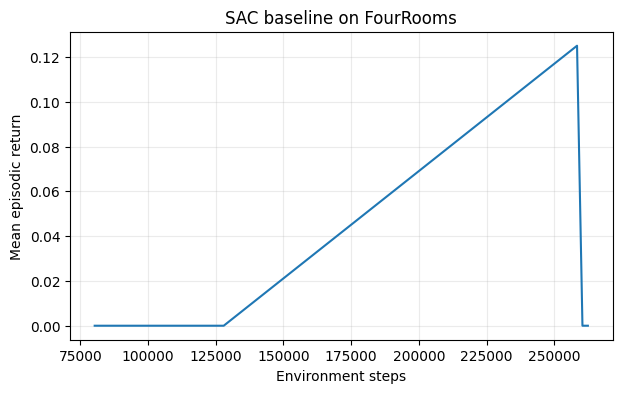

In [ ]:

def sac_train(total_steps=300000, warmup_steps=10000, batch_size=256, gamma=0.99, tau=0.005, lr=3e-4, alpha_lr=3e-4):
    
    env = make_env()
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]

    actor = SAC_Actor(obs_dim, act_dim).to(DEVICE)
    q1, q2 = SAC_Critic(obs_dim, act_dim).to(DEVICE), SAC_Critic(obs_dim, act_dim).to(DEVICE)
    q1_target, q2_target = SAC_Critic(obs_dim, act_dim).to(DEVICE), SAC_Critic(obs_dim, act_dim).to(DEVICE)


    q1_target.load_state_dict(q1.state_dict())
    q2_target.load_state_dict(q2.state_dict())

    for p in list(q1_target.parameters()) + list(q2_target.parameters()):
        p.requires_grad_(False)

    actor_opt = optim.Adam(actor.parameters(), lr=lr)
    q_opt = optim.Adam(list(q1.parameters()) + list(q2.parameters()), lr=lr)
    log_alpha = torch.tensor(np.log(0.8), dtype=torch.float32, device=DEVICE, requires_grad=True)
    alpha_opt = optim.Adam([log_alpha], lr=alpha_lr)
    target_entropy = -float(act_dim)

    replay = TrajectoryReplayBuffer(capacity=100000, obs_dim=obs_dim, action_dim=act_dim, device=DEVICE)
    total_env_steps = 0
    grad_steps = 0
    eval_returns = []

    while total_env_steps < warmup_steps:
        ep, n = collect_episode(env, lambda _: env.action_space.sample())
        replay.add_episode(ep)
        total_env_steps += n

    while total_env_steps < total_steps:
        def policy(obs):
            obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            with torch.no_grad():
                a, _ = actor.sample(obs_t)
            return a.squeeze(0).cpu().numpy().astype(np.float32)

        ep, n = collect_episode(env, policy)
        replay.add_episode(ep)
        total_env_steps += n

        for _ in range(max(1, n // 2)):
            batch = replay.sample(batch_size)
            obs = batch.obs.float()
            act = batch.actions.float()
            rew = batch.rewards.float()
            next_obs = batch.next_obs.float()
            done = torch.clamp(batch.terminated + batch.truncated, 0, 1).float()

            with torch.no_grad():
                next_a, next_logp = actor.sample(next_obs)
                target_q = torch.min(q1_target(next_obs, next_a), q2_target(next_obs, next_a)) - log_alpha.exp() * next_logp
                y = rew + gamma * (1 - done) * target_q

            q_loss = F.mse_loss(q1(obs, act), y) + F.mse_loss(q2(obs, act), y)
            q_opt.zero_grad()
            q_loss.backward()
            q_opt.step()

            new_a, logp = actor.sample(obs)
            q_pi = torch.min(q1(obs, new_a), q2(obs, new_a))
            actor_loss = (log_alpha.exp().detach() * logp - q_pi).mean()
            actor_opt.zero_grad()
            actor_loss.backward()
            actor_opt.step()

            alpha_loss = -(log_alpha * (-logp.detach() - target_entropy)).mean()
            alpha_opt.zero_grad()
            alpha_loss.backward()
            alpha_opt.step()

            with torch.no_grad():
                for p, pt in zip(q1.parameters(), q1_target.parameters()):
                    pt.data.mul_(1 - tau).add_(tau * p.data)
                for p, pt in zip(q2.parameters(), q2_target.parameters()):
                    pt.data.mul_(1 - tau).add_(tau * p.data)

            grad_steps += 1

        if grad_steps % 200 == 0:
            eval_env = make_env()
            mean_ret, mean_len = evaluate_policy(
                eval_env,
                lambda o: torch.tanh(
                    actor(torch.tensor(o, dtype=torch.float32, device=DEVICE).unsqueeze(0))[0]
                ).squeeze(0).detach().cpu().numpy().astype(np.float32),
                episodes=8,
            )
            eval_returns.append((total_env_steps, mean_ret))
            print(f'[SAC] step={total_env_steps:7d} | eval_return={mean_ret:.3f} | eval_len={mean_len:.1f}')
            eval_env.close()

    env.close()
    return actor, q1, eval_returns


sac_actor, sac_q1, sac_eval = sac_train()

if sac_eval:
    xs, ys = zip(*sac_eval)
    plt.figure(figsize=(7, 4))
    plt.plot(xs, ys)
    plt.xlabel('Environment steps')
    plt.ylabel('Mean episodic return')
    plt.title('SAC baseline on FourRooms')
    plt.grid(alpha=0.25)
    plt.show()


## Visualisations

Episode 1: 500 steps | return: 0.00 | reached goal: False
Episode 2: 500 steps | return: 0.00 | reached goal: False
Episode 3: 500 steps | return: 0.00 | reached goal: False
Episode 4: 500 steps | return: 0.00 | reached goal: False
Episode 5: 500 steps | return: 0.00 | reached goal: False
Episode 6: 500 steps | return: 0.00 | reached goal: False
Episode 7: 500 steps | return: 0.00 | reached goal: False
Episode 8: 500 steps | return: 0.00 | reached goal: False

Success rate: 0.00% over 8 episodes
Average return: 0.00 ± 0.00


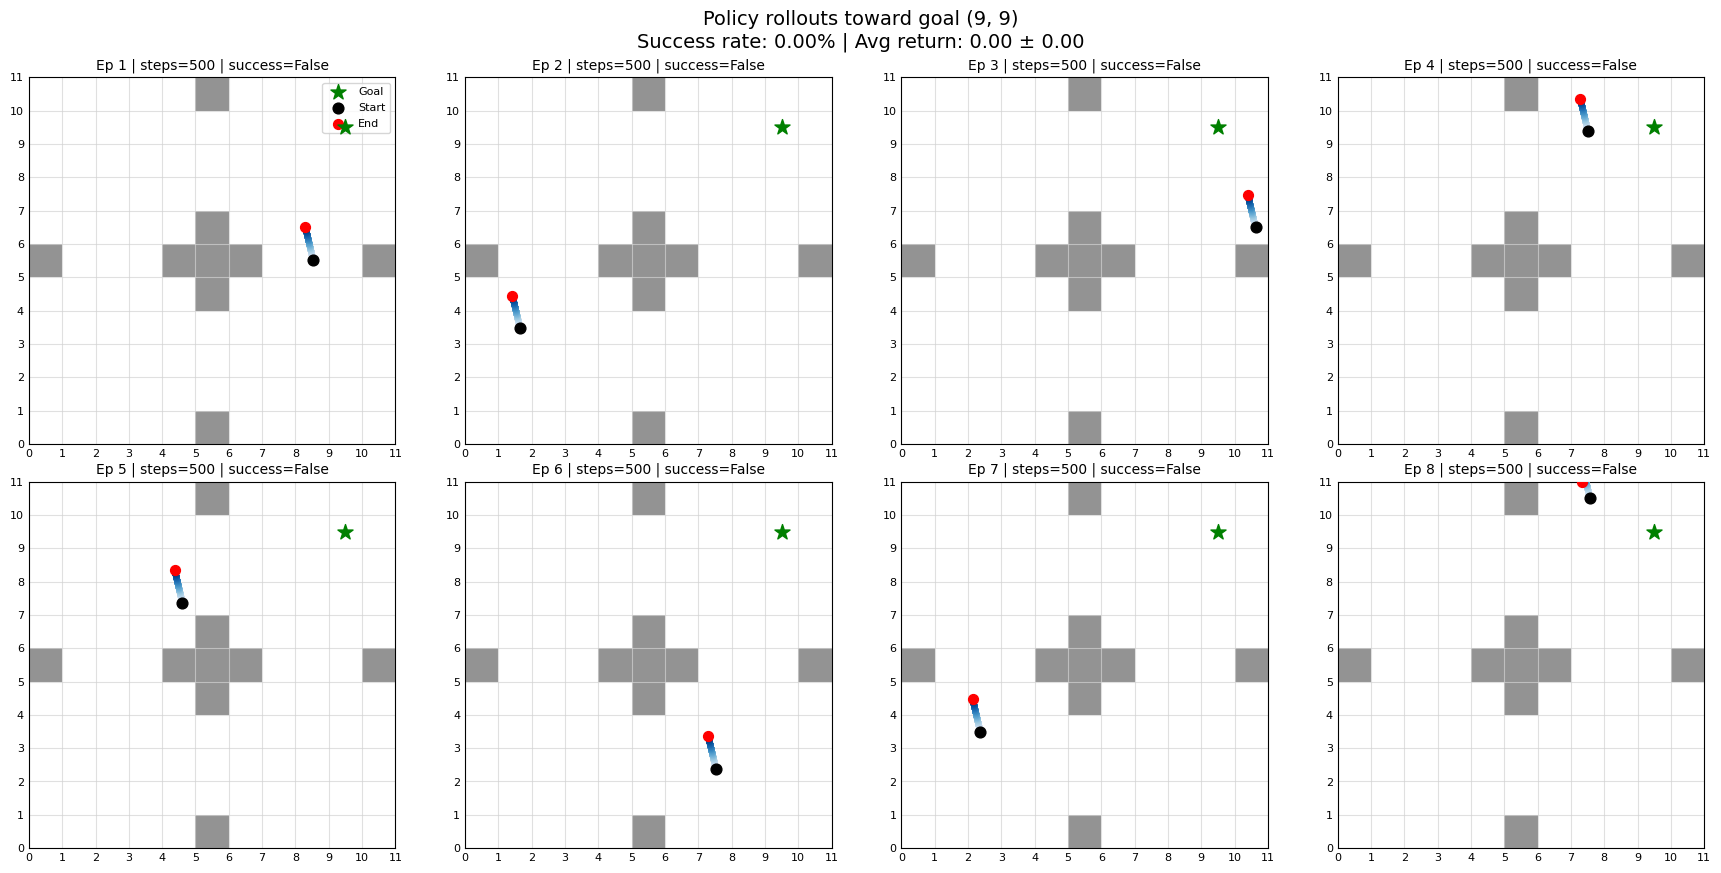

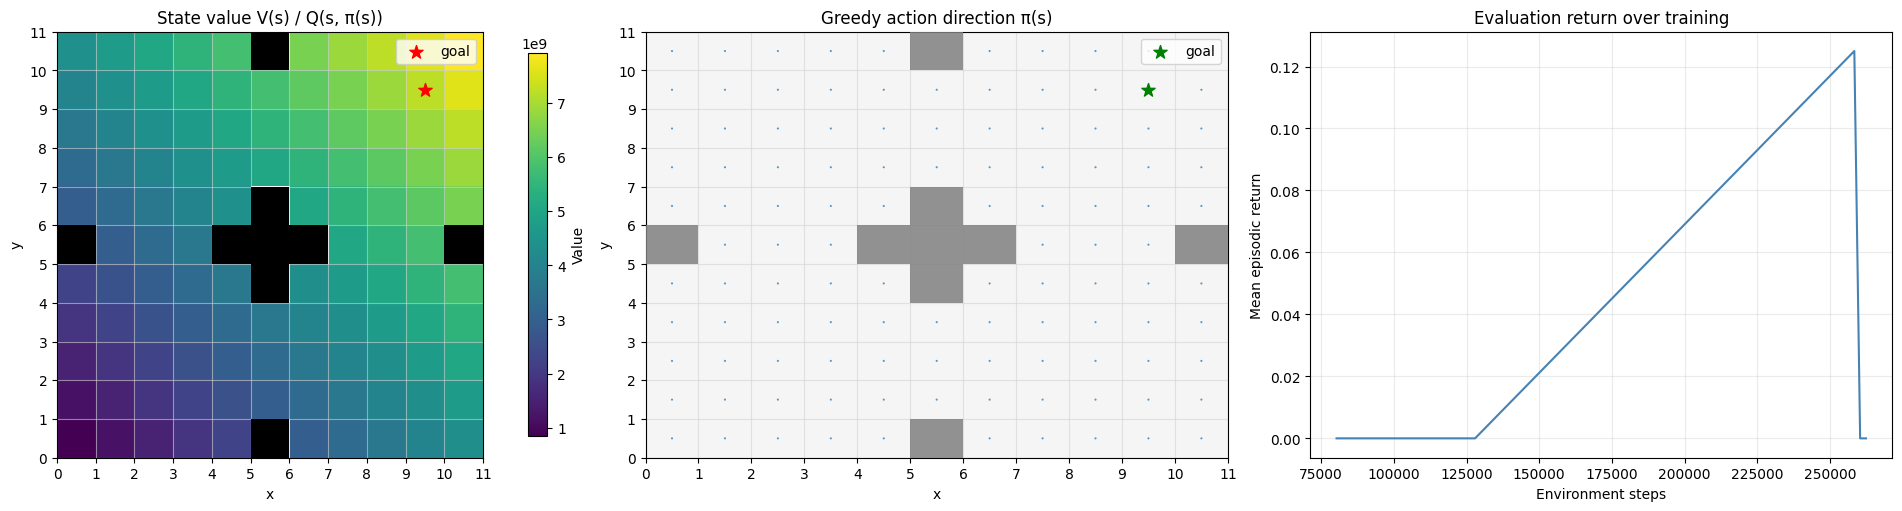

In [5]:

sac_actor.eval()
sac_q1.eval()

eval_env = make_env(goal=(9, 9))


def sac_policy_fn(obs):
    obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        mu, _ = sac_actor(obs_t)
        action = torch.tanh(mu).squeeze(0).cpu().numpy().astype(np.float32)
    return action


def sac_value_fn(obs_batch):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        mu, _ = sac_actor(obs_t)
        a = torch.tanh(mu)
        q = sac_q1(obs_t, a).squeeze(-1).cpu().numpy()
    return q


def sac_actor_fn(obs_batch):
    obs_t = torch.tensor(obs_batch, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        mu, _ = sac_actor(obs_t)
        actions = torch.tanh(mu).cpu().numpy()
    return actions


plot_policy_rollouts(
    env=eval_env,
    policy_fn=sac_policy_fn,
    goal_pos=(9, 9),
    eval_episodes=8,
    n_cols=4,
    is_discrete=False,
    step_point_size=12,
    start_size=60,
    end_size=50,
    goal_size=130,
    arrow_width=0.01,
)

eval_env.close()

eval_env = make_env(goal=(9, 9))

plot_q_diagnostics(
    env=eval_env,
    value_fn=sac_value_fn,
    actor_fn=sac_actor_fn,
    is_discrete=False,
    goal_pos=(9, 9),
    eval_returns=sac_eval,
)

eval_env.close()